# Feature Importance and Block Ablation — Section 7.4

Reuses the helpers in `organized/src/srwnba/analysis/`. All outputs land in
`organized/outputs/`.

**Outputs:**

| File | Purpose |
|---|---|
| `feature_block_ablation_logloss.png` | Block ablation, OOF + holdout |
| `feature_block_importance_with_vs_without_elo.png` | Block-share importance, with vs without Elo |
| `feature_top_gain_full_model.png` | Top-30 features by gain (xgb_with_elo) |
| `feature_top_gain_xgb_without_elo.png` | Top-30 features by gain (xgb_no_elo) |
| `feature_player_slot_importance.png` | Gain summed by player slot |
| `feature_logreg_top_coefficients.png` | Top-30 logreg coefficients (+ Elo) |

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

%matplotlib inline
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13, 'figure.dpi': 120})

ANALYSIS_DIR = Path('../..').resolve() / 'src' / 'srwnba' / 'analysis'
PIPELINE_DIR = Path('../..').resolve() / 'pipelines' / '05_modeling'
for d in (ANALYSIS_DIR, PIPELINE_DIR):
    if str(d) not in sys.path:
        sys.path.insert(0, str(d))

from final_model import FEAT_COLS, BLOCK_COLS, N_PLAYERS, feature_block
from walkforward import (
    walk_forward_models, fit_holdout_models, summarize_predictions,
    PAPER_MODEL_SPECS, PAPER_MODEL_LABELS,
)
from outputs import save_fig, save_table

BLOCK_COLORS = {'player': '#3498db', 'form': '#2ecc71', 'style': '#e67e22',
                'schedule': '#9b59b6', 'elo': '#e74c3c', 'other': '#95a5a6'}

OOF_YEARS = list(range(2020, 2025))
HOLDOUT_YEAR = 2025

---
## §7.4.1 — Feature block ablation
**Figure:** `feature_block_ablation_logloss`.

In [2]:
ABLATIONS = {
    'full':        FEAT_COLS,
    'no_player':   [c for c in FEAT_COLS if c not in BLOCK_COLS['player']],
    'no_form':     [c for c in FEAT_COLS if c not in BLOCK_COLS['form']],
    'no_style':    [c for c in FEAT_COLS if c not in BLOCK_COLS['style']],
    'no_schedule': [c for c in FEAT_COLS if c not in BLOCK_COLS['schedule']],
}

ablation_oof, ablation_hold = [], []
for name, cols in ABLATIONS.items():
    print(f'--- ablation: {name} ({len(cols)} features) ---')
    spec = {name: {'type': 'xgb', 'use_bm': True}}
    ablation_oof.append(walk_forward_models(spec, oof_years=OOF_YEARS, feat_cols=cols, verbose=False))
    h_df, _ = fit_holdout_models(spec, holdout_year=HOLDOUT_YEAR, feat_cols=cols, verbose=False)
    ablation_hold.append(h_df)

# also include Elo baseline for visual reference
elo_oof = walk_forward_models({'elo': {'type': 'elo'}}, oof_years=OOF_YEARS, verbose=False)
elo_hold, _ = fit_holdout_models({'elo': {'type': 'elo'}}, holdout_year=HOLDOUT_YEAR, verbose=False)

oof_all = pd.concat([elo_oof] + ablation_oof, ignore_index=True)
hold_all = pd.concat([elo_hold] + ablation_hold, ignore_index=True)

oof_summary = summarize_predictions(oof_all)
hold_summary = summarize_predictions(hold_all)
abl_table = (
    oof_summary.assign(period='OOF 2020–2024')
      .pipe(lambda d: pd.concat([d, hold_summary.assign(period='2025 Holdout')], ignore_index=True))
      [['period','model','log_loss','brier','accuracy','n_games']]
)
save_table(abl_table, 'feature_block_ablation_summary')
abl_table

--- ablation: full (160 features) ---
--- ablation: no_player (34 features) ---
--- ablation: no_form (150 features) ---
--- ablation: no_style (148 features) ---
--- ablation: no_schedule (148 features) ---
  saved: outputs\feature_block_ablation_summary.csv


,period,model,log_loss,brier,accuracy,n_games
0,OOF 2020–2024,elo,0.602163,0.207240,0.677708,1117
1,OOF 2020–2024,full,0.599394,0.205496,0.694718,1117
2,OOF 2020–2024,no_form,0.602179,0.206934,0.683080,1117
3,OOF 2020–2024,no_player,0.602488,0.207390,0.677708,1117
4,OOF 2020–2024,no_schedule,0.601711,0.206894,0.685765,1117
5,OOF 2020–2024,no_style,0.604345,0.208178,0.683080,1117
6,2025 Holdout,elo,0.615098,0.213165,0.667742,310
7,2025 Holdout,full,0.612148,0.211232,0.674194,310
8,2025 Holdout,no_form,0.625137,0.215800,0.654839,310
9,2025 Holdout,no_player,0.614433,0.212844,0.661290,310


  saved: outputs\feature_block_ablation_logloss.png


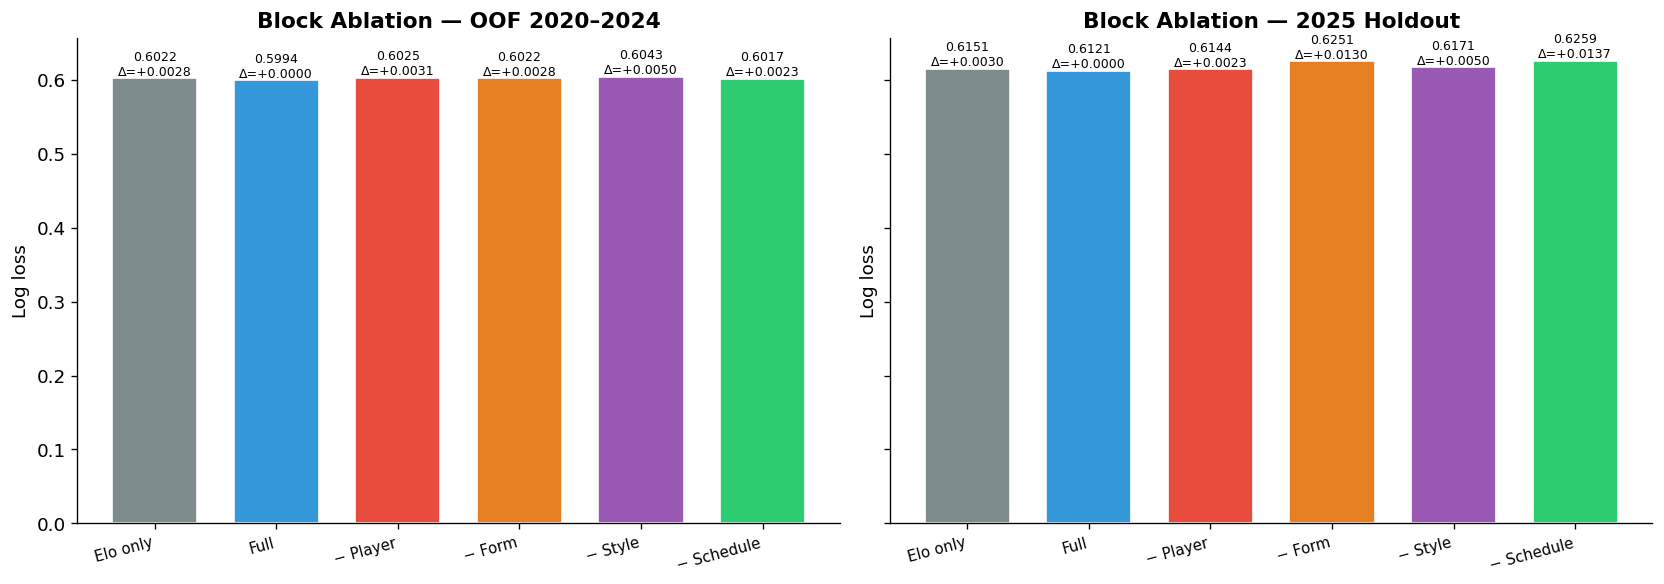

In [3]:
ABL_ORDER = ['elo', 'full', 'no_player', 'no_form', 'no_style', 'no_schedule']
ABL_COLORS = {'elo': '#7f8c8d', 'full': '#3498db', 'no_player': '#e74c3c',
              'no_form': '#e67e22', 'no_style': '#9b59b6', 'no_schedule': '#2ecc71'}
ABL_LABELS = {'elo': 'Elo only', 'full': 'Full', 'no_player': '− Player',
              'no_form': '− Form', 'no_style': '− Style', 'no_schedule': '− Schedule'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, period in zip(axes, ('OOF 2020–2024', '2025 Holdout')):
    sub = abl_table[abl_table['period'] == period].set_index('model').loc[ABL_ORDER]
    colors = [ABL_COLORS[m] for m in ABL_ORDER]
    bars = ax.bar(range(len(ABL_ORDER)), sub['log_loss'].values, color=colors, edgecolor='white', width=0.7)
    ax.set_xticks(range(len(ABL_ORDER)))
    ax.set_xticklabels([ABL_LABELS[m] for m in ABL_ORDER], rotation=15, ha='right', fontsize=9)
    ax.set_ylabel('Log loss')
    ax.set_title(f'Block Ablation — {period}', fontweight='bold')
    full_ll = sub.loc['full', 'log_loss']
    for bar, val in zip(bars, sub['log_loss'].values):
        delta = val - full_ll
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:.4f}\nΔ={delta:+.4f}', ha='center', va='bottom', fontsize=7.5)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
save_fig(fig, 'feature_block_ablation_logloss')
plt.show()

---
## §7.4.2 — Importance models
Train xgb_with_elo, xgb_no_elo, and logreg_with_elo on 2015–2024 with nested ES on 2024.
Reuses `fit_holdout_models` so the protocol matches forecasting.

In [4]:
_, artefacts = fit_holdout_models(
    {
        'xgb_with_elo':    {'type': 'xgb', 'use_bm': True},
        'xgb_no_elo':      {'type': 'xgb', 'use_bm': False},
        'logreg_with_elo': {'type': 'logreg', 'with_elo': True},
    },
    holdout_year=HOLDOUT_YEAR,
)
xgb_elo    = artefacts['xgb_with_elo']
xgb_no_elo = artefacts['xgb_no_elo']
lr_elo     = artefacts['logreg_with_elo']
print('Artefacts ready.')

  xgb_with_elo             best_round=88
  xgb_no_elo               best_round=325
Artefacts ready.


In [5]:
def importance_table(model):
    out = None
    for it in ('gain', 'weight', 'cover'):
        s = model.get_score(importance_type=it)
        df = pd.DataFrame({'feature': list(s.keys()), it: list(s.values())})
        out = df if out is None else out.merge(df, on='feature', how='outer')
    out = out.fillna(0)
    for it in ('gain', 'weight', 'cover'):
        out[f'{it}_norm'] = out[it] / out[it].sum()
    out['block'] = out['feature'].apply(feature_block)
    return out.sort_values('gain_norm', ascending=False).reset_index(drop=True)

fi_elo    = importance_table(xgb_elo)
fi_no_elo = importance_table(xgb_no_elo)
save_table(fi_elo,    'feature_importance_xgb_with_elo')
save_table(fi_no_elo, 'feature_importance_xgb_no_elo')
fi_elo.head(10)

  saved: outputs\feature_importance_xgb_with_elo.csv
  saved: outputs\feature_importance_xgb_no_elo.csv


,feature,gain,weight,cover,gain_norm,weight_norm,cover_norm,block
0,away_p5_played_last_game_pre,9.358229,1.0,25.649158,0.014553,0.000428,0.002732,player
1,home_p2_played_last_game_pre,8.349550,1.0,367.711456,0.012984,0.000428,0.039165,player
2,away_p2_played_last_game_pre,8.208813,2.0,116.386765,0.012765,0.000857,0.012396,player
3,away_p5_days_since_last_played_pre,8.031997,35.0,256.334351,0.012490,0.014996,0.027302,player
4,away_p5_days_since_first_report_pre,7.950523,16.0,344.396606,0.012364,0.006855,0.036682,player
5,away_days_rest_pre,7.950284,5.0,71.669365,0.012363,0.002142,0.007634,schedule
6,home_p6_played_last_game_pre,7.883388,2.0,176.533905,0.012259,0.000857,0.018803,player
7,away_p2_q_pre,7.806110,48.0,121.230408,0.012139,0.020566,0.012912,player
8,home_p1_q_pre,7.676269,55.0,139.660004,0.011937,0.023565,0.014875,player
9,away_p6_days_since_last_dnp_pre,7.645047,5.0,330.501221,0.011889,0.002142,0.035202,player


---
## §7.4.3 — Block importance: with-Elo vs without-Elo
**Figure:** `feature_block_importance_with_vs_without_elo`.

  saved: outputs\feature_block_importance_table.csv
  saved: outputs\feature_block_importance_with_vs_without_elo.png


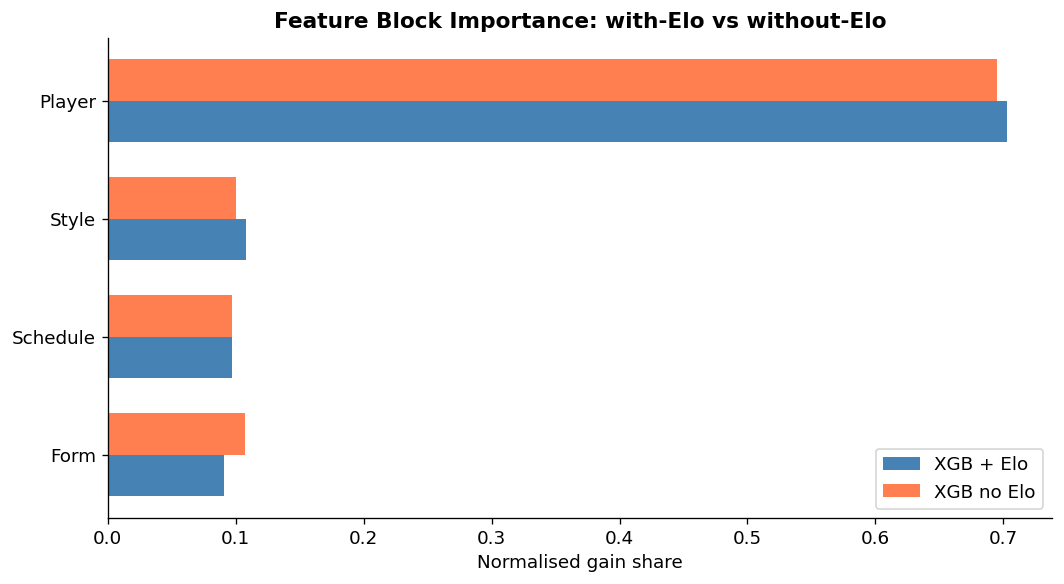

In [6]:
block_elo = fi_elo.groupby('block')['gain_norm'].sum().rename('with_elo')
block_ne  = fi_no_elo.groupby('block')['gain_norm'].sum().rename('no_elo')
block_cmp = pd.concat([block_elo, block_ne], axis=1).fillna(0).sort_values('with_elo')
save_table(block_cmp.reset_index(), 'feature_block_importance_table')

fig, ax = plt.subplots(figsize=(9, 5))
y = range(len(block_cmp)); w = 0.35
ax.barh([i - w/2 for i in y], block_cmp['with_elo'], w, label='XGB + Elo', color='steelblue')
ax.barh([i + w/2 for i in y], block_cmp['no_elo'],   w, label='XGB no Elo', color='coral')
ax.set_yticks(list(y)); ax.set_yticklabels(block_cmp.index.str.title())
ax.set_xlabel('Normalised gain share')
ax.set_title('Feature Block Importance: with-Elo vs without-Elo', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
save_fig(fig, 'feature_block_importance_with_vs_without_elo')
plt.show()

---
## §7.4 Appendix — Top features by gain

  saved: outputs\feature_top_gain_full_model.png


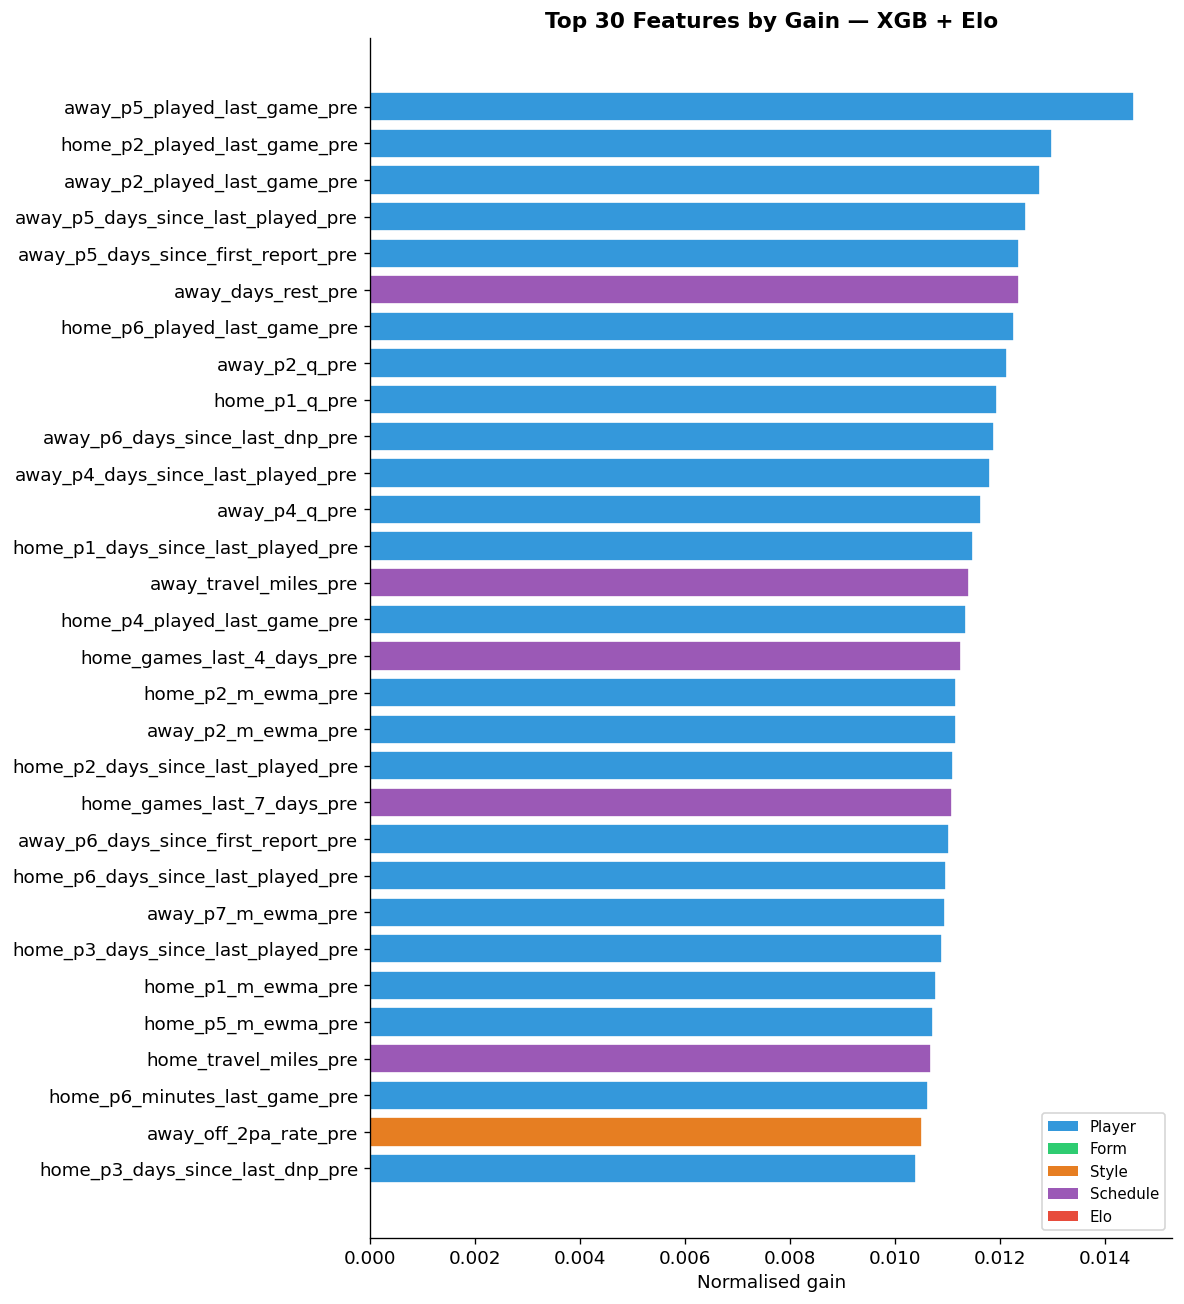

  saved: outputs\feature_top_gain_xgb_without_elo.png


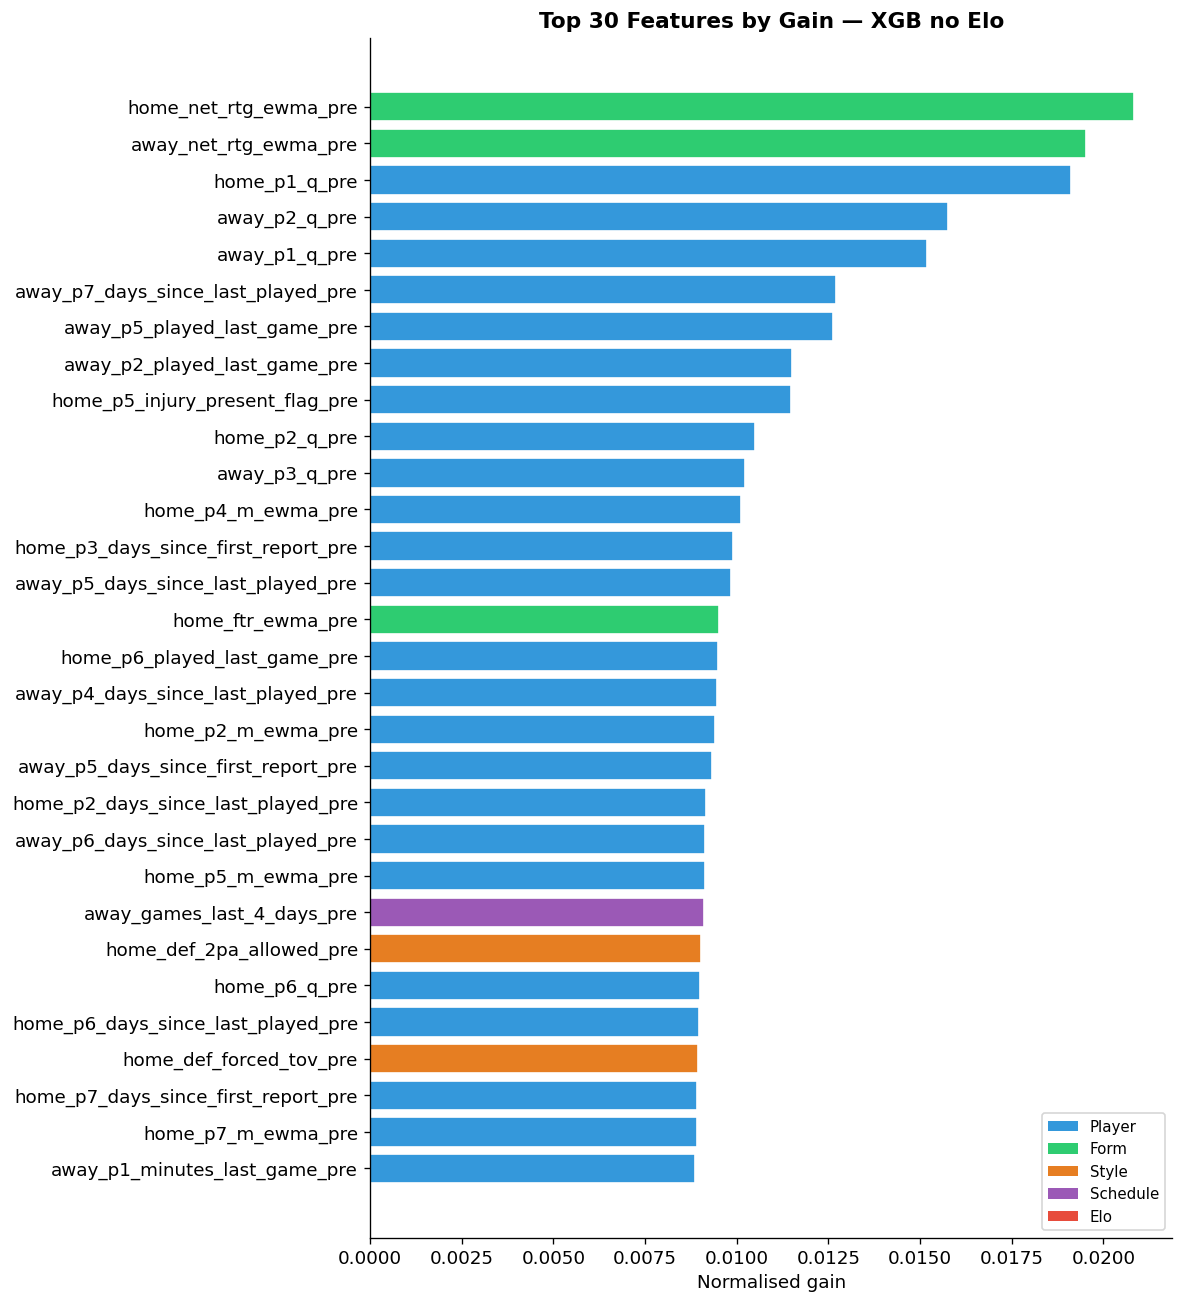

In [7]:
def plot_top_gain(fi, title, save_name, top_n=30):
    top = fi.head(top_n).sort_values('gain_norm')
    colors = [BLOCK_COLORS[b] for b in top['block']]
    fig, ax = plt.subplots(figsize=(10, 11))
    ax.barh(top['feature'], top['gain_norm'], color=colors, edgecolor='white')
    ax.set_xlabel('Normalised gain')
    ax.set_title(title, fontweight='bold')
    ax.legend(
        handles=[Patch(facecolor=c, label=b.title())
                 for b, c in BLOCK_COLORS.items() if b != 'other'],
        fontsize=9, loc='lower right',
    )
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout()
    save_fig(fig, save_name)
    plt.show()

plot_top_gain(fi_elo,    'Top 30 Features by Gain — XGB + Elo',     'feature_top_gain_full_model')
plot_top_gain(fi_no_elo, 'Top 30 Features by Gain — XGB no Elo',    'feature_top_gain_xgb_without_elo')

### Player slot importance
**Figure:** `feature_player_slot_importance`.

  saved: outputs\feature_player_slot_importance_table.csv
  saved: outputs\feature_player_slot_importance.png


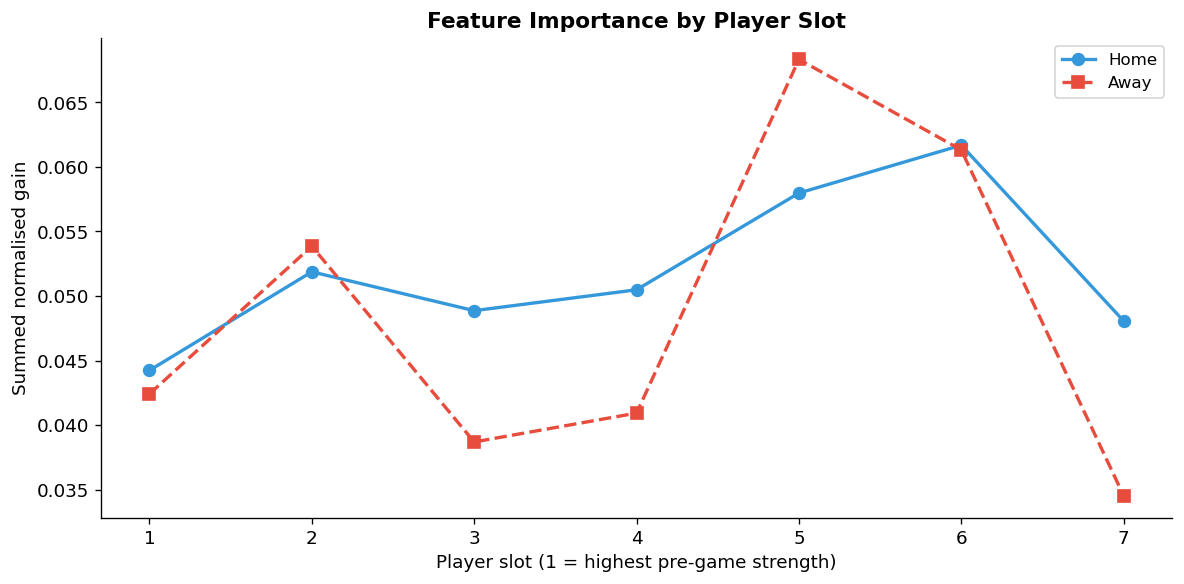

In [8]:
rows = []
for side in ('home', 'away'):
    for slot in range(1, N_PLAYERS + 1):
        prefix = f'{side}_p{slot}_'
        sub = fi_elo[fi_elo['feature'].str.startswith(prefix)]
        rows.append({'side': side, 'slot': slot,
                     'gain_sum': sub['gain_norm'].sum(),
                     'n_features': len(sub)})
slot_df = pd.DataFrame(rows)
save_table(slot_df, 'feature_player_slot_importance_table')

fig, ax = plt.subplots(figsize=(10, 5))
x = range(1, N_PLAYERS + 1)
ax.plot(x, slot_df[slot_df['side']=='home']['gain_sum'], '-o',
        color='#3498db', linewidth=2, markersize=7, label='Home')
ax.plot(x, slot_df[slot_df['side']=='away']['gain_sum'], '--s',
        color='#e74c3c', linewidth=2, markersize=7, label='Away')
ax.set_xlabel('Player slot (1 = highest pre-game strength)')
ax.set_ylabel('Summed normalised gain')
ax.set_title('Feature Importance by Player Slot', fontweight='bold')
ax.set_xticks(list(x))
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
save_fig(fig, 'feature_player_slot_importance')
plt.show()

### Logistic regression coefficients
**Figure:** `feature_logreg_top_coefficients`.

  saved: outputs\feature_logreg_coefficients.csv
  saved: outputs\feature_logreg_top_coefficients.png


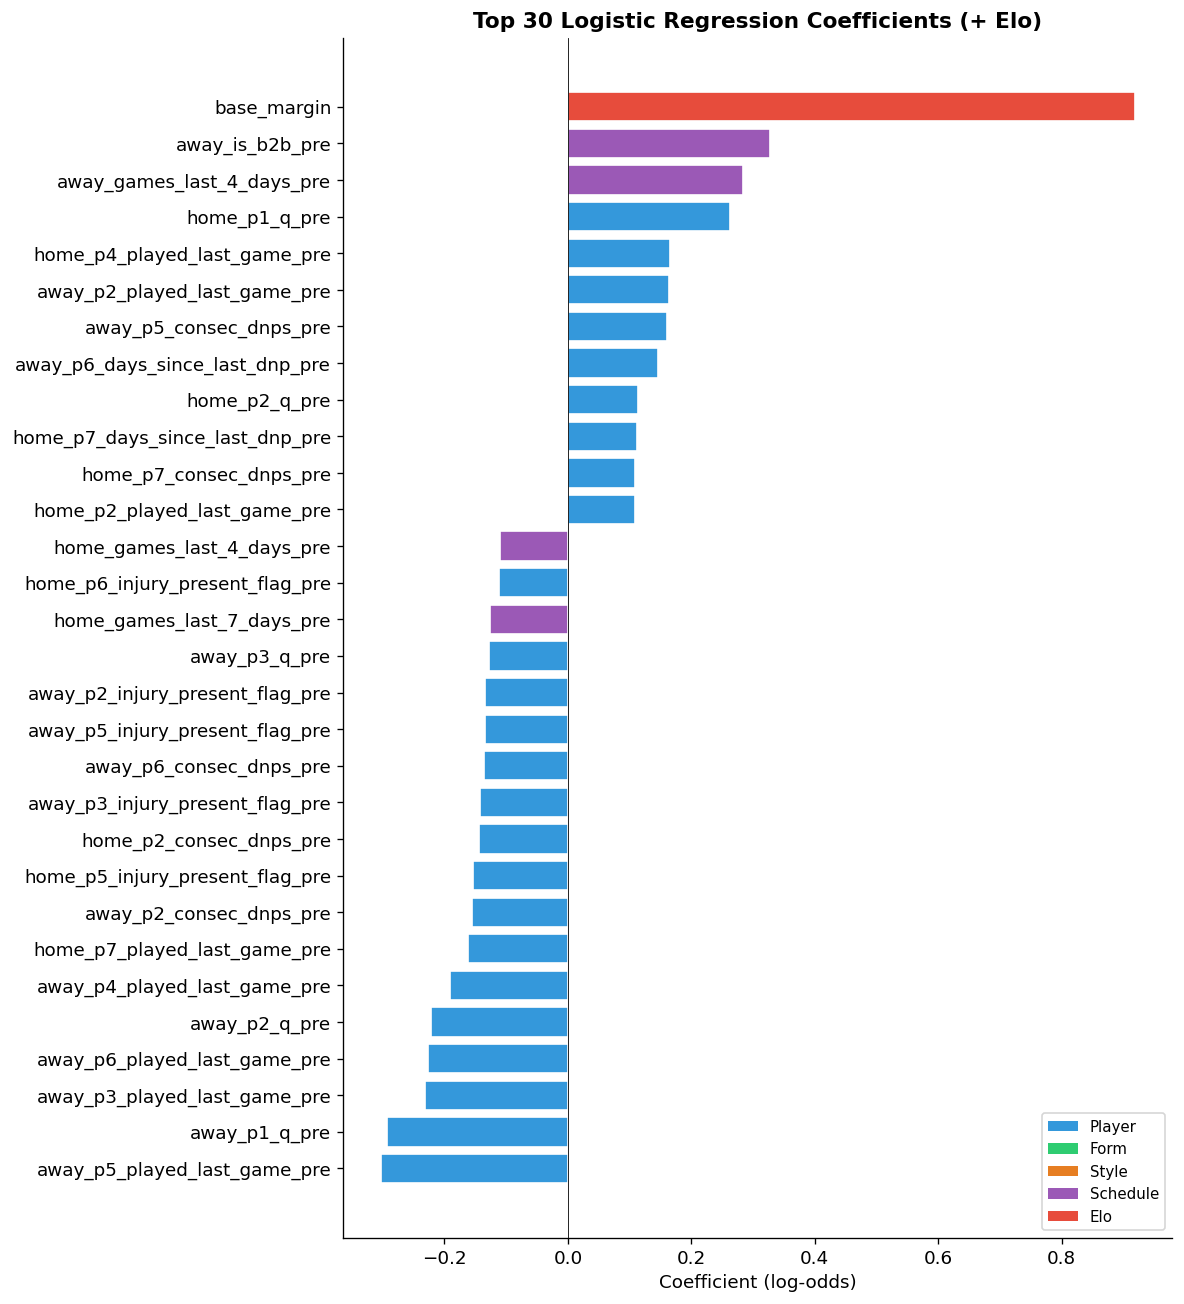

In [9]:
feat_names = ['base_margin'] + FEAT_COLS
coef = lr_elo.coef_[0]
# `lr_elo` was trained on [base_margin | features-in-train-order]; the order
# matches `FEAT_COLS` because walkforward._slice_arrays uses that same iteration.
coef_df = (
    pd.DataFrame({'feature': feat_names[:len(coef)], 'coefficient': coef})
    .assign(abs_coef=lambda d: d['coefficient'].abs(),
            block=lambda d: d['feature'].apply(
                lambda f: 'elo' if f == 'base_margin' else feature_block(f)))
    .sort_values('abs_coef', ascending=False).reset_index(drop=True)
)
save_table(coef_df, 'feature_logreg_coefficients')

top = coef_df.head(30).sort_values('coefficient')
colors = [BLOCK_COLORS[b] for b in top['block']]
fig, ax = plt.subplots(figsize=(10, 11))
ax.barh(top['feature'], top['coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Top 30 Logistic Regression Coefficients (+ Elo)', fontweight='bold')
ax.legend(handles=[Patch(facecolor=c, label=b.title()) for b, c in BLOCK_COLORS.items() if b != 'other'],
          fontsize=9, loc='lower right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
save_fig(fig, 'feature_logreg_top_coefficients')
plt.show()